In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle

In [2]:
# Step 2: Load Data
data_path = "../data/patient_data.csv"  # adjust path if needed
df = pd.read_csv(data_path)


In [3]:
# Step 3: Data Overview
print("First 5 rows:\n", df.head())
print("\nData Info:\n")
df.info()
print("\nSummary Statistics:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())

First 5 rows:
   Patient_ID  Age  Gender     Diagnosis Chronic_Disease  Previous_Visits  \
0      P0001   51  Female    Orthopedic              No               17   
1      P0002   14  Female  Hypertension              No               15   
2      P0003   71  Female       Cardiac              No                8   
3      P0004   60  Female  Hypertension             Yes               18   
4      P0005   20    Male           Flu              No                4   

   Treatment_Cost  
0            4565  
1            4848  
2            3095  
3            7189  
4            2228  

Data Info:

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Patient_ID       1000 non-null   str  
 1   Age              1000 non-null   int64
 2   Gender           1000 non-null   str  
 3   Diagnosis        1000 non-null   str  
 4   Chronic_Disease  1000 non-null  

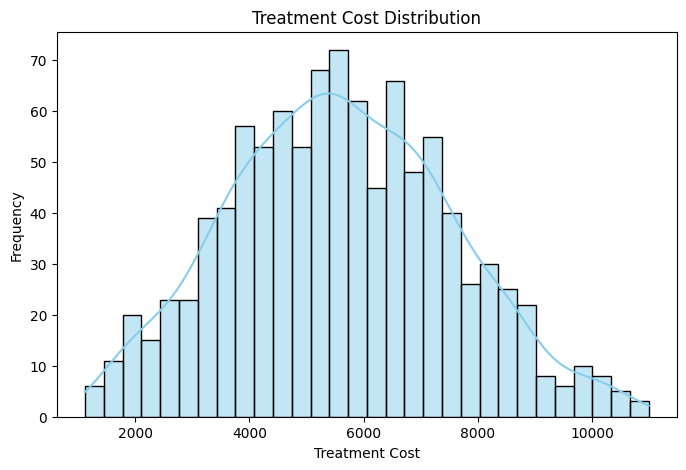

In [4]:
# Step 4: Exploratory Data Analysis (EDA)
# Distribution of Treatment Cost
plt.figure(figsize=(8,5))
sns.histplot(df['Treatment_Cost'], bins=30, kde=True, color='skyblue')
plt.title("Treatment Cost Distribution")
plt.xlabel("Treatment Cost")
plt.ylabel("Frequency")
plt.show()

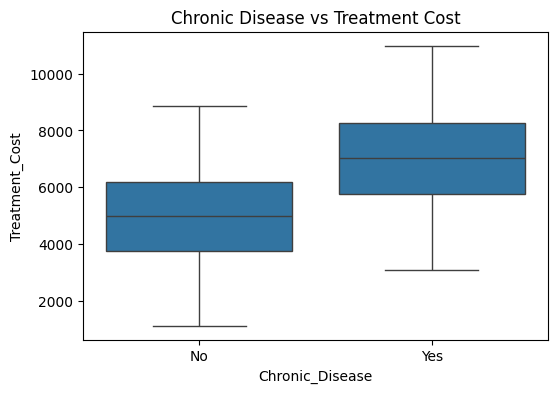

In [5]:
# Chronic Disease vs Treatment Cost
plt.figure(figsize=(6,4))
sns.boxplot(x='Chronic_Disease', y='Treatment_Cost', data=df)
plt.title("Chronic Disease vs Treatment Cost")
plt.show()

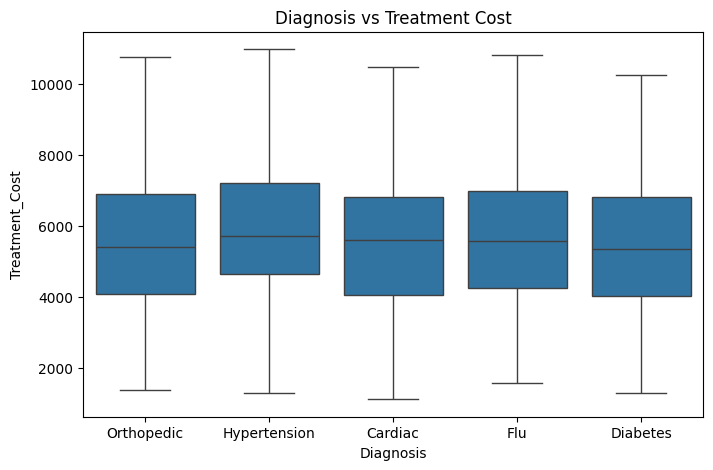

In [6]:
# Diagnosis vs Treatment Cost
plt.figure(figsize=(8,5))
sns.boxplot(x='Diagnosis', y='Treatment_Cost', data=df)
plt.title("Diagnosis vs Treatment Cost")
plt.show()

In [7]:

# Step 5: Data Preprocessing
# Convert categorical variables to numeric
df_encoded = pd.get_dummies(df, columns=['Gender','Diagnosis','Chronic_Disease'], drop_first=True)


In [8]:
# Features and Target
X = df_encoded.drop(['Patient_ID','Treatment_Cost'], axis=1)
y = df_encoded['Treatment_Cost']

In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Step 6: Model Training - Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
# Predictions
y_pred = rf_model.predict(X_test)

In [12]:
# Step 7: Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Random Forest RMSE: {rmse:.2f}")
print(f"Random Forest R2 Score: {r2:.2f}")

Random Forest RMSE: 1380.77
Random Forest R2 Score: 0.53


In [13]:
# Step 8: Save Model
model_path = "../outputs/trained_model.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)
print(f"Trained model saved to {model_path}")

Trained model saved to ../outputs/trained_model.pkl


In [14]:
# Step 9: Show Top 10 High-Cost Patients
df['Predicted_Cost'] = rf_model.predict(X)
top_patients = df.sort_values(by='Predicted_Cost', ascending=False).head(10)
print("\nTop 10 High-Cost Patients:\n", top_patients[['Patient_ID','Predicted_Cost']])


Top 10 High-Cost Patients:
     Patient_ID  Predicted_Cost
841      P0842    10253.060000
404      P0405    10099.390000
955      P0956    10071.700000
919      P0920     9983.711000
925      P0926     9901.476667
52       P0053     9898.850000
612      P0613     9563.330000
398      P0399     9519.550000
666      P0667     9509.280000
920      P0921     9476.990000
